In [16]:
from extract_features import extractHG, stackFeatures, extractMelSpecs, downsampleLabels, nameVector

import os
import numpy as np
import pandas as pd
import scipy
import scipy.signal
import scipy.stats
import scipy.io.wavfile
import scipy.fftpack

from pynwb import NWBHDF5IO

import scipy.io.wavfile as wavfile
from scipy.stats import pearsonr
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

import reconstructWave as rW
import MelFilterBank as mel

from reconstruction_minimal import createAudio
import matplotlib.pyplot as plt
import matplotlib

In [19]:
path_bids = r'./SingleWordProductionDutch-iBIDS'
path_output = r'./features'
feat_path = r'./features'
result_path = r'./results'

In [23]:
winL = 0.05
frameshift = 0.01
modelOrder = 4
stepSize = 5

In [20]:
participants = pd.read_csv(os.path.join(path_bids,'participants.tsv'), delimiter='\t')
for p_id, participant in enumerate(participants['participant_id']):
    print(p_id, participant)

0 sub-01
1 sub-02
2 sub-03
3 sub-04
4 sub-05
5 sub-06
6 sub-07
7 sub-08
8 sub-09
9 sub-10


In [32]:
# extract features
participants = pd.read_csv(os.path.join(path_bids,'participants.tsv'), delimiter='\t')
for p_id, participant in enumerate(participants['participant_id']):
        
    #Load data
    io = NWBHDF5IO(os.path.join(path_bids,participant,'ieeg',f'{participant}_task-wordProduction_ieeg.nwb'), 'r')
    nwbfile = io.read()
    #sEEG
    eeg = nwbfile.acquisition['iEEG'].data[:]
    eeg_sr = 1024
    #audio
    audio = nwbfile.acquisition['Audio'].data[:]
    audio_sr = 48000
    #words (markers)
    words = nwbfile.acquisition['Stimulus'].data[:]
    words = np.array(words, dtype=str)
    io.close()
    #channels
    channels = pd.read_csv(os.path.join(path_bids,participant,'ieeg',f'{participant}_task-wordProduction_channels.tsv'), delimiter='\t')
    channels = np.array(channels['name'])

    #Extract HG features
    feat = extractHG(eeg,eeg_sr, windowLength=winL,frameshift=frameshift)

    #Stack features
    feat = stackFeatures(feat,modelOrder=modelOrder,stepSize=stepSize)
        
    #Process Audio
    target_SR = 16000
    audio = scipy.signal.decimate(audio,int(audio_sr / target_SR))
    audio_sr = target_SR
    scaled = np.int16(audio/np.max(np.abs(audio)) * 32767)
    os.makedirs(os.path.join(path_output), exist_ok=True)
    scipy.io.wavfile.write(os.path.join(path_output,f'{participant}_orig_audio.wav'),audio_sr,scaled)   

    #Extract spectrogram
    melSpec = extractMelSpecs(scaled,audio_sr,windowLength=winL,frameshift=frameshift)
        
    #Align to EEG features
    words = downsampleLabels(words,eeg_sr,windowLength=winL,frameshift=frameshift)
    words = words[modelOrder*stepSize:words.shape[0]-modelOrder*stepSize]
    melSpec = melSpec[modelOrder*stepSize:melSpec.shape[0]-modelOrder*stepSize,:]
    #adjust length (differences might occur due to rounding in the number of windows)
    if melSpec.shape[0]!=feat.shape[0]:
        tLen = np.min([melSpec.shape[0],feat.shape[0]])
        melSpec = melSpec[:tLen,:]
        feat = feat[:tLen,:]
        
    #Create feature names by appending the temporal shift 
    feature_names = nameVector(channels[:,None], modelOrder=modelOrder)

    #Save everything
#     np.save(os.path.join(path_output,f'{participant}_feat.npy'), feat)
#     np.save(os.path.join(path_output,f'{participant}_procWords.npy'), words)
#     np.save(os.path.join(path_output,f'{participant}_spec.npy'), melSpec)
#     np.save(os.path.join(path_output,f'{participant}_feat_names.npy'), feature_names)

In [83]:
feature_names

array(['RC1T-4', 'RC2T-4', 'RC3T-4', ..., 'RZ8T4', 'RZ9T4', 'RZ10T4'],
      dtype='<U10')

In [84]:
words

array(['5', '5', '5', ..., '', '', ''], dtype='<U12')

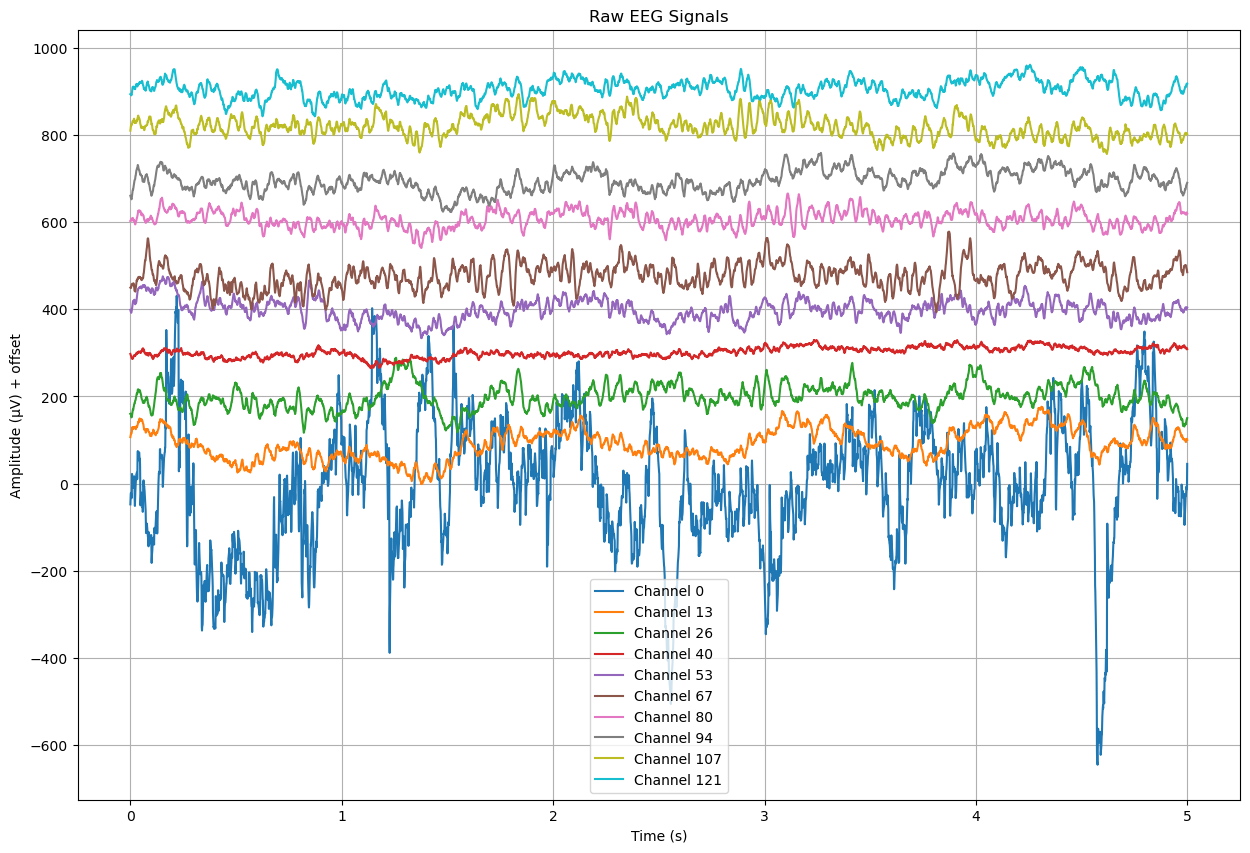

In [6]:
# Plot a few seconds of raw EEG data for a few channels
def plot_raw_eeg(eeg_data, sample_rate, duration=5, channels_to_plot=10):
    # Convert duration to samples
    samples = int(duration * sample_rate)
    
    # Select a subset of channels if there are many
    if eeg_data.shape[1] > channels_to_plot:
        channel_indices = np.linspace(0, eeg_data.shape[1]-1, channels_to_plot, dtype=int)
    else:
        channel_indices = range(eeg_data.shape[1])
    
    plt.figure(figsize=(15, 10))
    for i, ch_idx in enumerate(channel_indices):
        # Offset each channel for visibility
        offset = i * 100  # Adjust based on signal amplitude
        plt.plot(np.arange(samples)/sample_rate, 
                 eeg_data[:samples, ch_idx] + offset, 
                 label=f'Channel {ch_idx}')
    
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (μV) + offset')
    plt.title('Raw EEG Signals')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_raw_eeg(eeg, eeg_sr)

In [39]:
# reconstruction minimal
pts = ['sub-%02d'%i for i in range(1,11)]

winLength = 0.05
frameshift = 0.01
audiosr = 16000

nfolds = 10
kf = KFold(nfolds,shuffle=False)
est = LinearRegression(n_jobs=5)
pca = PCA()
numComps = 50
    
#Initialize empty matrices for correlation results, randomized contols and amount of explained variance
allRes = np.zeros((len(pts),nfolds,23))
explainedVariance = np.zeros((len(pts),nfolds))
numRands = 1000
randomControl = np.zeros((len(pts),numRands, 23))

for pNr, pt in enumerate(pts):
    #Load the data
    spectrogram = np.load(os.path.join(feat_path,f'{pt}_spec.npy'))
    data = np.load(os.path.join(feat_path,f'{pt}_feat.npy'))
    labels = np.load(os.path.join(feat_path,f'{pt}_procWords.npy'))
    featName = np.load(os.path.join(feat_path,f'{pt}_feat_names.npy'))
        
#     #Initialize an empty spectrogram to save the reconstruction to
#     rec_spec = np.zeros(spectrogram.shape)
#     #Save the correlation coefficients for each fold
#     rs = np.zeros((nfolds,spectrogram.shape[1]))
#     for k,(train, test) in enumerate(kf.split(data)):
#         #Z-Normalize with mean and std from the training data
#         mu=np.mean(data[train,:],axis=0)
#         std=np.std(data[train,:],axis=0)
#         trainData=(data[train,:]-mu)/std
#         testData=(data[test,:]-mu)/std

#         #Fit PCA to training data
#         pca.fit(trainData)
#         #Get percentage of explained variance by selected components
#         explainedVariance[pNr,k] =  np.sum(pca.explained_variance_ratio_[:numComps])
#         #Tranform data into component space
#         trainData=np.dot(trainData, pca.components_[:numComps,:].T)
#         testData = np.dot(testData, pca.components_[:numComps,:].T)
            
#         #Fit the regression model
#         est.fit(trainData, spectrogram[train, :])
#         #Predict the reconstructed spectrogram for the test data
#         rec_spec[test, :] = est.predict(testData)

#         #Evaluate reconstruction of this fold
#         for specBin in range(spectrogram.shape[1]):
#             if np.any(np.isnan(rec_spec)):
#                 print('%s has %d broken samples in reconstruction' % (pt, np.sum(np.isnan(rec_spec))))
#             r, p = pearsonr(spectrogram[test, specBin], rec_spec[test, specBin])
#             rs[k,specBin] = r

#     #Show evaluation result
#     print('%s has mean correlation of %f' % (pt, np.mean(rs)))
#     allRes[pNr,:,:]=rs

#     #Estimate random baseline
#     for randRound in range(numRands):
#         #Choose a random splitting point at least 10% of the dataset size away
#         splitPoint = np.random.choice(np.arange(int(spectrogram.shape[0]*0.1),int(spectrogram.shape[0]*0.9)))
#         #Swap the dataset on the splitting point 
#         shuffled = np.concatenate((spectrogram[splitPoint:,:],spectrogram[:splitPoint,:]))
#         #Calculate the correlations
#         for specBin in range(spectrogram.shape[1]):
#             if np.any(np.isnan(rec_spec)):
#                 print('%s has %d broken samples in reconstruction' % (pt, np.sum(np.isnan(rec_spec))))
#             r, p = pearsonr(spectrogram[:,specBin], shuffled[:,specBin])
#             randomControl[pNr, randRound,specBin]=r


#     #Save reconstructed spectrogram
#     os.makedirs(os.path.join(result_path), exist_ok=True)
#     np.save(os.path.join(result_path,f'{pt}_predicted_spec.npy'), rec_spec)
        
#     #Synthesize waveform from spectrogram using Griffin-Lim
#     reconstructedWav = createAudio(rec_spec,audiosr=audiosr,winLength=winLength,frameshift=frameshift)
#     wavfile.write(os.path.join(result_path,f'{pt}_predicted.wav'),int(audiosr),reconstructedWav)

#     #For comparison synthesize the original spectrogram with Griffin-Lim
#     origWav = createAudio(spectrogram,audiosr=audiosr,winLength=winLength,frameshift=frameshift)
#     wavfile.write(os.path.join(result_path,f'{pt}_orig_synthesized.wav'),int(audiosr),origWav)

#Save results in numpy arrays          
# np.save(os.path.join(result_path,'linearResults.npy'),allRes)
# np.save(os.path.join(result_path,'randomResults.npy'),randomControl)
# np.save(os.path.join(result_path,'explainedVariance.npy'),explainedVariance)

In [85]:
labels

array(['5', '5', '5', ..., '', '', ''], dtype='<U12')

In [27]:
channels_df = pd.read_csv(os.path.join(path_bids, participant, 'ieeg', 
                         f'{participant}_task-wordProduction_channels.tsv'), 
                         delimiter='\t')

In [28]:
# Get a count of channels by brain region
brain_regions = channels_df['description'].value_counts()
print("Channels by brain region:")
print(brain_regions)

# Look for speech-related areas
speech_related_terms = ['front', 'temporal', 'sylvian', 'wernicke', 'broca', 
                       'inferior', 'superior temporal', 'angular', 'supramarginal']

speech_areas = []
for i, row in channels_df.iterrows():
    desc = str(row['description']).lower()
    if any(term in desc for term in speech_related_terms):
        speech_areas.append((row['name'], row['description']))

print("\nPotential speech-related channels:")
for name, desc in speech_areas:
    print(f"{name}: {desc}")

# Check for left hemisphere channels
left_hemisphere = channels_df[channels_df['name'].str.startswith('L') | 
                              channels_df['description'].str.contains('left|lh')]
print(f"\nNumber of left hemisphere channels: {len(left_hemisphere)}")

Channels by brain region:
description
Right-Cerebral-White-Matter         47
Unknown                             15
ctx_rh_G_front_sup                   9
ctx_rh_G_parietal_sup                5
ctx_rh_S_intrapariet_and_P_trans     5
ctx_rh_S_temporal_sup                5
ctx_rh_G_temporal_middle             4
ctx_rh_S_cingul-Marginalis           4
ctx_rh_S_subparietal                 4
ctx_rh_G_temp_sup-Plan_tempo         3
ctx_rh_G_and_S_cingul-Mid-Ant        3
Right-Hippocampus                    3
Right-Lateral-Ventricle              3
ctx_rh_S_front_sup                   2
ctx_rh_G_pariet_inf-Angular          2
ctx_rh_G_pariet_inf-Supramar         2
ctx_rh_G_front_middle                1
ctx_rh_G_cingul-Post-dorsal          1
ctx_rh_G_temp_sup-G_T_transv         1
ctx_rh_Lat_Fis-post                  1
ctx_rh_S_postcentral                 1
ctx_rh_G_and_S_paracentral           1
Name: count, dtype: int64

Potential speech-related channels:
RF1: ctx_rh_G_front_sup
RF2: ctx_rh_G_fron

In [29]:
# Define groups of speech-relevant channels by region
speech_channel_groups = {
    'superior_temporal': ['RH6', 'RH7', 'RH8', 'RT7', 'RT8'],  # Auditory processing
    'middle_temporal': ['RH10', 'RT9', 'RT10', 'RT11'],        # Semantic processing
    'angular_gyrus': ['RP13', 'RP14'],                         # Reading/language integration
    'frontal': ['RF1', 'RF2', 'RF4', 'RF5', 'RM1', 'RM2',      # Executive aspects
                'RQ1', 'RQ2', 'RQ4', 'RW10']
}

# Convert channel names to indices
def get_channel_indices(channel_names, channels_df):
    indices = []
    for name in channel_names:
        matching_rows = channels_df[channels_df['name'] == name]
        if not matching_rows.empty:
            indices.append(matching_rows.index[0])
    return indices

# Get indices for each group
speech_indices = {}
for group_name, channel_names in speech_channel_groups.items():
    speech_indices[group_name] = get_channel_indices(channel_names, channels_df)
    print(f"{group_name}: {len(speech_indices[group_name])} channels")

# Combine all speech-related indices
all_speech_indices = []
for indices in speech_indices.values():
    all_speech_indices.extend(indices)
print(f"Total speech-related channels: {len(all_speech_indices)}")

superior_temporal: 5 channels
middle_temporal: 4 channels
angular_gyrus: 2 channels
frontal: 10 channels
Total speech-related channels: 21


In [34]:
def analyze_individual_channels(eeg_data, spectrogram, channels_df, 
                               windowLength=0.05, frameshift=0.01, 
                               modelOrder=4, stepSize=5, numComps=10):
    """
    Analyze each channel individually to see its contribution to speech reconstruction
    
    Parameters:
    -----------
    eeg_data : numpy array
        EEG data with shape [samples, channels]
    spectrogram : numpy array
        Target spectrogram to reconstruct
    channels_df : pandas DataFrame
        Dataframe containing channel information
    
    Returns:
    --------
    channel_results : dict
        Dictionary with channel names as keys and correlation values as values
    """
    print("Analyzing individual channel contributions...")
    
    # Setup for cross-validation
    nfolds = 5  # Using fewer folds for speed
    kf = KFold(nfolds, shuffle=False)
    est = LinearRegression()
    pca = PCA()
    
    # Store results
    channel_results = {}
    
    # Loop through each channel
    for chan_idx in range(eeg_data.shape[1]):
        # Get channel name
        if chan_idx < len(channels_df):
            chan_name = channels_df.iloc[chan_idx]['name']
            chan_region = channels_df.iloc[chan_idx]['description']
        else:
            chan_name = f"Channel_{chan_idx}"
            chan_region = "Unknown"
            
        print(f"Processing {chan_name} ({chan_region})... ", end="")
        
        # Extract single channel data
        single_chan_data = eeg_data[:, [chan_idx]]
        
        # Extract high-gamma features
        try:
            feat = extractHG(single_chan_data, 1024, windowLength=windowLength, frameshift=frameshift)
            
            # Stack features
            feat = stackFeatures(feat, modelOrder=modelOrder, stepSize=stepSize)
            
            # Ensure the feature length matches the spectrogram
            if feat.shape[0] != spectrogram.shape[0]:
                min_len = min(feat.shape[0], spectrogram.shape[0])
                feat = feat[:min_len, :]
                spec_for_analysis = spectrogram[:min_len, :]
            else:
                spec_for_analysis = spectrogram
            
            # Initialize for cross-validation
            rec_spec = np.zeros((feat.shape[0], spec_for_analysis.shape[1]))
            rs = np.zeros((nfolds, spec_for_analysis.shape[1]))
            
            # Run cross-validation
            for k, (train, test) in enumerate(kf.split(feat)):
                # Skip if training set is too small
                if len(train) < 10 or len(test) < 10:
                    continue
                    
                # Normalize
                mu = np.mean(feat[train,:], axis=0)
                std = np.std(feat[train,:], axis=0)
                std[std == 0] = 1  # Avoid division by zero
                trainData = (feat[train,:] - mu) / std
                testData = (feat[test,:] - mu) / std
                
                # Use fewer components for single channel data
                n_components = min(numComps, trainData.shape[1], trainData.shape[0])
                if n_components < 2:
                    # Skip if too few components
                    print("Skipping - insufficient data")
                    continue
                
                # PCA
                try:
                    pca = PCA(n_components=n_components)
                    pca.fit(trainData)
                    trainData = pca.transform(trainData)
                    testData = pca.transform(testData)
                    
                    # Train model
                    est.fit(trainData, spec_for_analysis[train, :])
                    rec_spec[test, :] = est.predict(testData)
                    
                    # Evaluate
                    for specBin in range(spec_for_analysis.shape[1]):
                        r, p = pearsonr(spec_for_analysis[test, specBin], rec_spec[test, specBin])
                        rs[k, specBin] = r
                except Exception as e:
                    print(f"Error in PCA/regression: {e}")
                    continue
            
        except Exception as e:
            print(f"Error processing channel: {e}")
            channel_results[chan_name] = {
                'correlation': np.nan,
                'region': chan_region,
                'index': chan_idx
            }
    
    return channel_results

In [41]:
eeg_data = eeg
analyze_individual_channels(eeg_data, spectrogram, channels_df, 
                               windowLength=0.05, frameshift=0.01, 
                               modelOrder=4, stepSize=5, numComps=10)

Analyzing individual channel contributions...
Processing RC1 (ctx_rh_G_cingul-Post-dorsal)... Correlation: 0.189622
Processing RC2 (Right-Cerebral-White-Matter)... Correlation: 0.209561
Processing RC3 (Right-Cerebral-White-Matter)... Correlation: 0.316795
Processing RC4 (Right-Cerebral-White-Matter)... Correlation: 0.398089
Processing RC5 (Right-Cerebral-White-Matter)... Correlation: 0.386640
Processing RC7 (Right-Cerebral-White-Matter)... Correlation: 0.438468
Processing RC8 (Right-Cerebral-White-Matter)... Correlation: 0.444953
Processing RC9 (Right-Cerebral-White-Matter)... Correlation: 0.423630
Processing RC10 (Right-Cerebral-White-Matter)... Correlation: 0.406156
Processing RC11 (Right-Cerebral-White-Matter)... Correlation: 0.402014
Processing RC12 (ctx_rh_S_postcentral)... Correlation: 0.043879
Processing RC13 (Right-Cerebral-White-Matter)... Correlation: 0.373134
Processing RC14 (Right-Cerebral-White-Matter)... Correlation: 0.341527
Processing RC15 (ctx_rh_G_pariet_inf-Supramar)

{'RC1': {'correlation': 0.18962223014373286,
  'region': 'ctx_rh_G_cingul-Post-dorsal',
  'index': 0},
 'RC2': {'correlation': 0.20956062231166633,
  'region': 'Right-Cerebral-White-Matter',
  'index': 1},
 'RC3': {'correlation': 0.3167951856419907,
  'region': 'Right-Cerebral-White-Matter',
  'index': 2},
 'RC4': {'correlation': 0.3980887050536554,
  'region': 'Right-Cerebral-White-Matter',
  'index': 3},
 'RC5': {'correlation': 0.3866403216638172,
  'region': 'Right-Cerebral-White-Matter',
  'index': 4},
 'RC7': {'correlation': 0.43846843081376846,
  'region': 'Right-Cerebral-White-Matter',
  'index': 5},
 'RC8': {'correlation': 0.4449528621756169,
  'region': 'Right-Cerebral-White-Matter',
  'index': 6},
 'RC9': {'correlation': 0.42363040495408566,
  'region': 'Right-Cerebral-White-Matter',
  'index': 7},
 'RC10': {'correlation': 0.4061556066994772,
  'region': 'Right-Cerebral-White-Matter',
  'index': 8},
 'RC11': {'correlation': 0.40201368853217945,
  'region': 'Right-Cerebral-Whi

Found 95 word onsets
Processing word 'vijf' (length=4, duration=2.78s)
  Mean correlation: 0.5439 (using 23 frequency bins)
Processing word 'naar' (length=4, duration=2.99s)
  Mean correlation: 0.7778 (using 23 frequency bins)
Processing word 'braadde' (length=7, duration=3.00s)
  Mean correlation: 0.8509 (using 23 frequency bins)
Processing word 'zo' (length=2, duration=3.00s)
  Mean correlation: 0.8823 (using 23 frequency bins)
Processing word 'onmiddellijk' (length=12, duration=3.00s)
  Mean correlation: 0.8651 (using 23 frequency bins)
Processing word 'verstijfde' (length=10, duration=3.00s)
  Mean correlation: 0.8219 (using 23 frequency bins)
Processing word 'door' (length=4, duration=3.00s)
  Mean correlation: 0.6156 (using 23 frequency bins)
Processing word 'tien' (length=4, duration=3.00s)
  Mean correlation: 0.6912 (using 23 frequency bins)
Processing word '12' (length=2, duration=3.00s)
  Mean correlation: 0.8136 (using 23 frequency bins)
Processing word 'hem' (length=3, dura

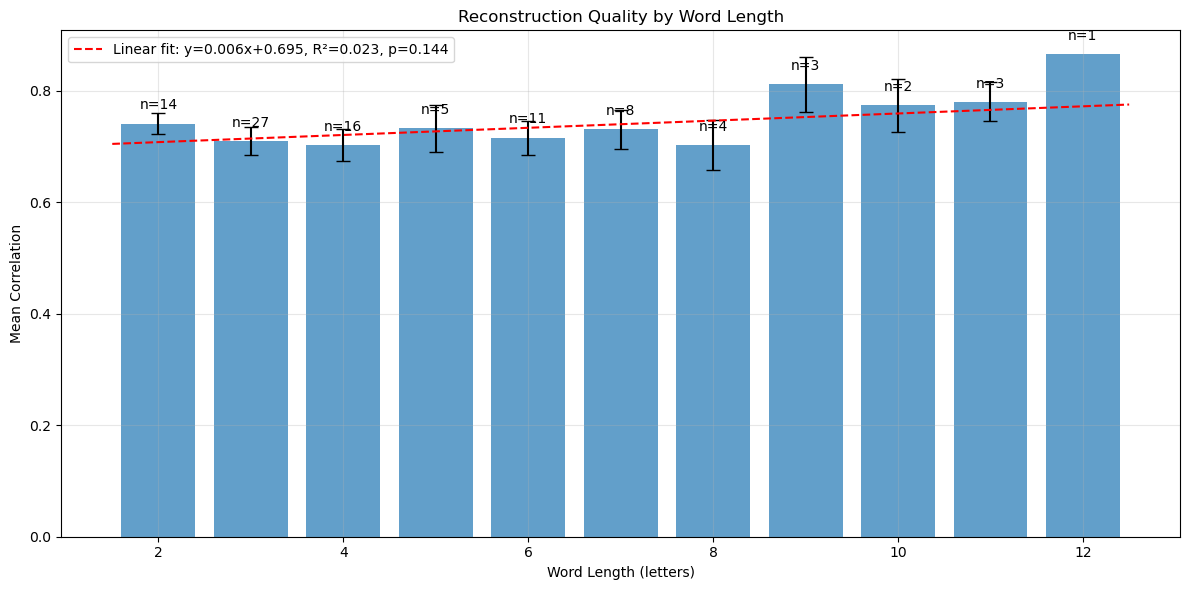

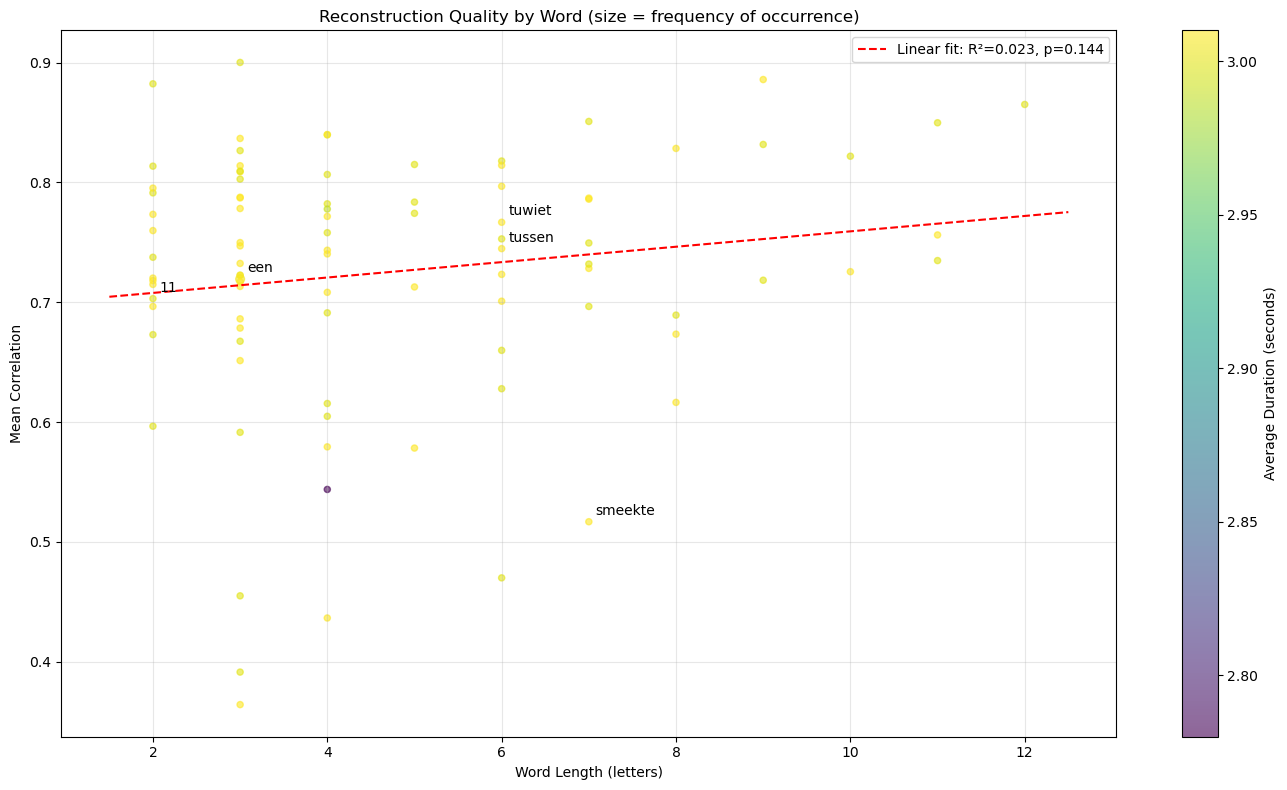

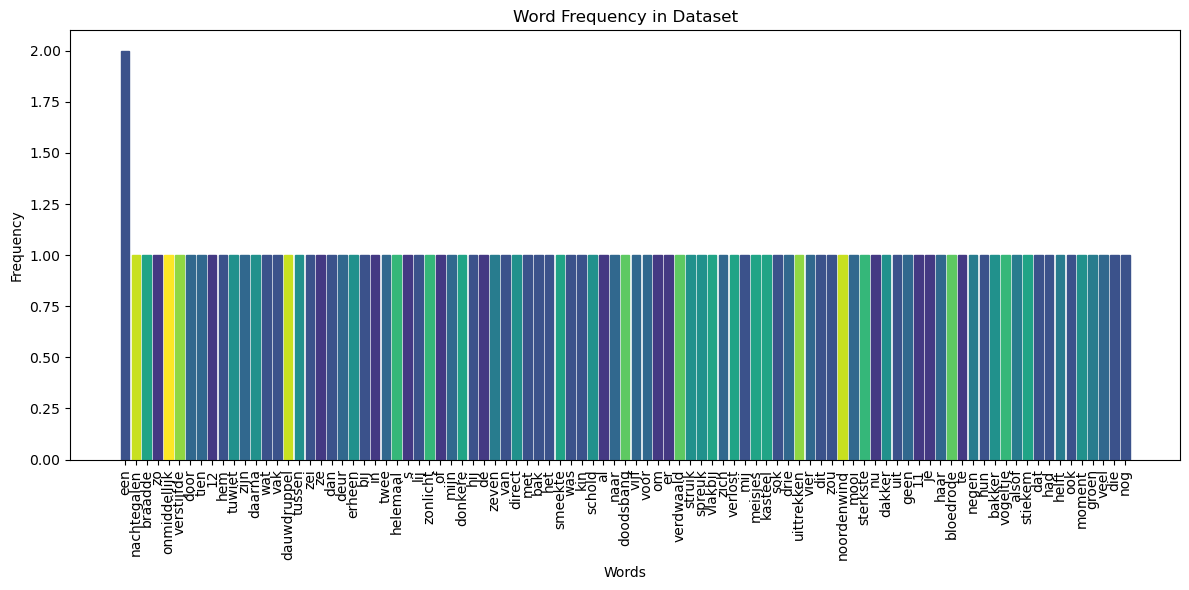

In [43]:
word_df, length_stats = analyze_word_length_correlation(spectrogram, rec_spec, labels)

In [ ]:
def extract_word_list(words):
    """
    Extract a list of unique words and their frequencies from the words array
    
    Parameters:
    -----------
    words : array
        Array of word labels at each time point
    
    Returns:
    --------
    word_list : pandas DataFrame
        DataFrame with columns 'word', 'count', 'length', and 'frequency'
    """

    # Convert numbers 1-10 to Dutch words
    dutch_numbers = {
        '1': 'een', '2': 'twee', '3': 'drie', '4': 'vier', '5': 'vijf',
        '6': 'zes', '7': 'zeven', '8': 'acht', '9': 'negen', '10': 'tien'
    }
    
    # Function to convert any numeric strings to Dutch words
    def convert_to_dutch(word):
        if word in dutch_numbers:
            return dutch_numbers[word]
        # Numbers 1-10
        if isinstance(word, str) and word.isdigit() and int(word) <= 10 and int(word) >= 1:
            return dutch_numbers[word]
        return word
    
    # Find word onsets (when words change)
    word_onsets = []
    current_word = ""
    
    for i, word in enumerate(words):
        # Ensure word is a string
        if not isinstance(word, str):
            word = str(word).strip()
            
        # Skip empty strings
        if word == "":
            continue
            
        # Convert numbers to Dutch words
        word = convert_to_dutch(word)
        
        # Detect word changes (onsets)
        if word != current_word:
            word_onsets.append((i, word))
            current_word = word
    
    print(f"Found {len(word_onsets)} word onsets")
    
    # Count word frequencies
    word_counts = {}
    for _, word in word_onsets:
        word_counts[word] = word_counts.get(word, 0) + 1
    
    # Create DataFrame
    word_list = pd.DataFrame({
        'word': list(word_counts.keys()),
        'count': list(word_counts.values()),
        'length': [len(w) for w in word_counts.keys()]
    })
    
    # Calculate frequency (percentage)
    total_words = len(word_onsets)
    word_list['frequency'] = word_list['count'] / total_words * 100
    
    # Sort by count (descending)
    word_list = word_list.sort_values('count', ascending=False).reset_index(drop=True)
    
    print(f"Found {len(word_list)} unique words")
    print(f"Top 10 most frequent words:")
    print(word_list.head(10))
    
    return word_list

In [7]:
# Manually create pronunciation dictionary
manual_dict = {
    'een': 'en',
    'vijf': 'vɛif',
    'sok': 'sɔk',
    'nu': 'ny',
    'mooi': 'moj',
    'noordenwind': 'nordənwɪnt',
    'zou': 'ˈzʏlə(n)',
    'dit': 'dɪt',
    'vier': 'vir',
    'uittrekken': 'ˈœytrɛkə(n)',
    'drie': 'dri',
    'sterkste': 'stɛrkstə',
    'dakker': 'dakɛr',
    'meisjes': 'mɛiʃəs',
    'mij': 'mɛi',
    'verlost': 'vərˈlɔst',
    'zich': 'zɪx',
    'vlakbij': "'vlɑg'bɛi",
    'spreuk': 'sprøk',
    'struik': 'strœyk',
    'verdwaald': 'vərˈdwalt',
    'er': 'ɛr',
    'voor': 'vor',
    'vogeltje': 'voxəlcə',
    'doodsbang': 'ˈdotsbɑŋ',
    'stiekem': 'ˈstikəm',
    'nog': 'nɔx',
    'die': 'di',
    'veel': 'vel',
    'groen': 'xrun',
    'moment': 'moˈmɛnt',
    'ook': 'ok',
    'helft': 'hɛlft',
    'had': 'hɑt',
    'dat': 'dɑt',
    'geen': 'xen',
    'kasteel': 'kɑsˈtel',
    'alsof': 'ɑlsˈɔf',
    'bakker': 'ˈbɑkər',
    'hun': 'hʏn',
    'negen': 'ˈnexə(n)',
    'te': 'tə',
    'bloedrode': 'blutrodə',
    'haar': 'har',
    'je': 'jə',
    'elf': 'ɛlf',
    'om': 'ɔm',
    'uit': 'œyt',
    'naar': 'nar',
    'zijn': 'zɛin',
    'bij': 'bɛi',
    'deur': 'dɵ:r',
    'dan': 'dɑn',
    'ze': 'zɛ',
    'zei': 'zɛi',
    'tussen': 'ˈtʏsə(n)',
    'dauwdruppel': 'dɑuˈdrʏpəl',
    'vak': 'vɑk',
    'wat': 'wɑt',
    'nachtegalen': 'ˈnɑxtəxal',
    'daarna': 'darˈna',
    'hem': 'hɛm',
    'twaalf': 'twalf',
    'tien': 'tin',
    'door': 'dor',
    'verstijfde': "vər'stɛivə(n)",
    'onmiddellijk': 'ɔnˈmɪdələk',
    'zo': 'zo',
    'braadde': 'ˈbradə',
    'erheen': "ɛr'hen",
    'in': 'ɪn',
    'helemaal': 'ˈheləmal',
    'twee': 'twe',
    'al': 'ɑl',
    'schold': 'ˈsxold',
    'kin': 'kɪn',
    'was': 'wɑs',
    'smeekte': 'ˈsmektə(n)',
    'het': 'hɛt',
    'bak': 'bɑk',
    'met': 'mɛt',
    'direct': 'diˈrɛkt',
    'van': 'vɑn',
    'zeven': 'ˈzevə(n)',
    'de': 'də',
    'hij': 'hɛi',
    'donkere': 'ˈdɔŋkərə',
    'mijn': 'mɛin',
    'of': 'ɔf',
    'zonlicht': 'ˈzɔnlɪxt',
    'lij': 'lɛi',
    'zevenduizend': 'ˈzevə(n)ˈdœyzənt'
}


In [ ]:
from sklearn.preprocessing import StandardScaler

In [9]:
def run_existing_model(save_results=True, force_rerun=False):
    """
    Run the existing spectrogram reconstruction model,
    or load existing results if available
    
    Parameters:
    -----------
    save_results : bool
        Whether to save the results to disk
    force_rerun : bool
        Whether to force rerunning the model even if results exist
        
    Returns:
    --------
    all_results : dict
        Dictionary with results for all participants
    """
    feat_path = './features'
    result_path = './results'
    
    # Create results directory if it doesn't exist
    if save_results:
        os.makedirs(result_path, exist_ok=True)
    
    pts = ['sub-%02d'%i for i in range(1,11)]
    
    # Store results for each participant
    participant_results = {}
    
    # Check if we need to run the model at all
    all_results_exist = True
    missing_participants = []
    
    if not force_rerun:
        for pt in pts:
            # Check if reconstructed spectrogram exists
            spec_path = os.path.join(result_path, f'{pt}_predicted_spec.npy')
            if not os.path.exists(spec_path):
                all_results_exist = False
                missing_participants.append(pt)
    else:
        all_results_exist = False
        missing_participants = pts
    
    # If all results exist, just load them
    if all_results_exist:
        print("All results already exist. Loading from disk...")
        
        for pt in pts:
            # Load the original and reconstructed spectrograms
            try:
                spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
                rec_spec = np.load(os.path.join(result_path, f'{pt}_predicted_spec.npy'))
                
                # Calculate correlations
                correlations = []
                for specBin in range(spectrogram.shape[1]):
                    r, _ = pearsonr(spectrogram[:, specBin], rec_spec[:, specBin])
                    correlations.append(r)
                
                mean_correlation = np.mean(correlations)
                print(f"  {pt} reconstruction correlation: {mean_correlation:.4f}")
                
                # Store results
                participant_results[pt] = {
                    'reconstructed_spec': rec_spec,
                    'correlations': np.array(correlations),
                    'mean_correlation': mean_correlation
                }
                
                # Try to load random baseline if it exists
                try:
                    randomControl = np.load(os.path.join(result_path, 'randomResults.npy'))
                    participant_results[pt]['random_baseline'] = np.mean(randomControl[pts.index(pt), :, :])
                except:
                    participant_results[pt]['random_baseline'] = None
            
            except Exception as e:
                print(f"  Error loading results for {pt}: {e}")
        
        return participant_results
    
    # Otherwise, run the model for missing participants
    print(f"Need to run model for {len(missing_participants)} participants: {missing_participants}")
    
    # First load any existing results
    if not force_rerun:
        for pt in pts:
            if pt not in missing_participants:
                try:
                    # Load existing results
                    spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
                    rec_spec = np.load(os.path.join(result_path, f'{pt}_predicted_spec.npy'))
                    
                    # Calculate correlations
                    correlations = []
                    for specBin in range(spectrogram.shape[1]):
                        r, _ = pearsonr(spectrogram[:, specBin], rec_spec[:, specBin])
                        correlations.append(r)
                    
                    mean_correlation = np.mean(correlations)
                    print(f"  Loaded existing results for {pt}: {mean_correlation:.4f}")
                    
                    # Store results
                    participant_results[pt] = {
                        'reconstructed_spec': rec_spec,
                        'correlations': np.array(correlations),
                        'mean_correlation': mean_correlation
                    }
                    
                    # Try to load random baseline if it exists
                    try:
                        randomControl = np.load(os.path.join(result_path, 'randomResults.npy'))
                        participant_results[pt]['random_baseline'] = np.mean(randomControl[pts.index(pt), :, :])
                    except:
                        participant_results[pt]['random_baseline'] = None
                
                except Exception as e:
                    print(f"  Error loading results for {pt}: {e}")
                    missing_participants.append(pt)
    
    # Run the model for missing participants
    if missing_participants:
        print("Running model for missing participants...")
        
        winLength = 0.05
        frameshift = 0.01
        audiosr = 16000

        nfolds = 10
        kf = KFold(nfolds, shuffle=False)
        est = LinearRegression(n_jobs=5)
        pca = PCA()
        numComps = 50
        
        # Initialize matrices for correlation results and explained variance
        # (only for participants we're actually computing)
        allRes = np.zeros((len(missing_participants), nfolds, 23))
        explainedVariance = np.zeros((len(missing_participants), nfolds))
        numRands = 1000
        randomControl = np.zeros((len(missing_participants), numRands, 23))
        
        # Try to load existing overall results if we're not forcing a rerun
        if not force_rerun:
            try:
                existingRes = np.load(os.path.join(result_path, 'linearResults.npy'))
                existingVar = np.load(os.path.join(result_path, 'explainedVariance.npy'))
                existingRand = np.load(os.path.join(result_path, 'randomResults.npy'))
            except:
                existingRes = None
                existingVar = None
                existingRand = None
        else:
            existingRes = None
            existingVar = None
            existingRand = None

        for i, pt in enumerate(missing_participants):
            print(f"Processing {pt} with existing reconstruction model...")
            pt_idx = pts.index(pt)  # Index in the full list
            
            # Load the data
            spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
            data = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
            
            # Initialize an empty spectrogram to save the reconstruction to
            rec_spec = np.zeros(spectrogram.shape)
            
            # Save the correlation coefficients for each fold
            rs = np.zeros((nfolds, spectrogram.shape[1]))
            
            for k, (train, test) in enumerate(kf.split(data)):
                # Z-Normalize with mean and std from the training data
                mu = np.mean(data[train, :], axis=0)
                std = np.std(data[train, :], axis=0)
                trainData = (data[train, :] - mu) / std
                testData = (data[test, :] - mu) / std

                # Fit PCA to training data
                pca.fit(trainData)
                
                # Get percentage of explained variance by selected components
                explainedVariance[i, k] = np.sum(pca.explained_variance_ratio_[:numComps])
                
                # Transform data into component space
                trainData = np.dot(trainData, pca.components_[:numComps, :].T)
                testData = np.dot(testData, pca.components_[:numComps, :].T)
                
                # Fit the regression model
                est.fit(trainData, spectrogram[train, :])
                
                # Predict the reconstructed spectrogram for the test data
                rec_spec[test, :] = est.predict(testData)

                # Evaluate reconstruction of this fold
                for specBin in range(spectrogram.shape[1]):
                    if np.any(np.isnan(rec_spec)):
                        print(f'{pt} has {np.sum(np.isnan(rec_spec))} broken samples in reconstruction')
                    r, p = pearsonr(spectrogram[test, specBin], rec_spec[test, specBin])
                    rs[k, specBin] = r

            # Show evaluation result
            mean_correlation = np.mean(rs)
            print(f'{pt} has mean correlation of {mean_correlation:.4f}')
            allRes[i, :, :] = rs

            # Estimate random baseline
            pt_random_baseline = []
            for randRound in range(numRands):
                # Choose a random splitting point at least 10% of the dataset size away
                splitPoint = np.random.choice(np.arange(int(spectrogram.shape[0]*0.1), int(spectrogram.shape[0]*0.9)))
                
                # Swap the dataset on the splitting point 
                shuffled = np.concatenate((spectrogram[splitPoint:, :], spectrogram[:splitPoint, :]))
                
                # Calculate the correlations
                for specBin in range(spectrogram.shape[1]):
                    r, p = pearsonr(spectrogram[:, specBin], shuffled[:, specBin])
                    randomControl[i, randRound, specBin] = r
                    pt_random_baseline.append(r)
            
            # Store participant results
            participant_results[pt] = {
                'reconstructed_spec': rec_spec,
                'correlations': rs,
                'mean_correlation': mean_correlation,
                'random_baseline': np.mean(pt_random_baseline)
            }
            
            # Save reconstructed spectrogram
            if save_results:
                np.save(os.path.join(result_path, f'{pt}_predicted_spec.npy'), rec_spec)

        # Merge with existing results if available
        if save_results:
            # Create full result arrays
            fullRes = np.zeros((len(pts), nfolds, 23))
            fullVar = np.zeros((len(pts), nfolds))
            fullRand = np.zeros((len(pts), numRands, 23))
            
            # Fill with existing results if available
            if existingRes is not None and existingRes.shape == fullRes.shape:
                fullRes = existingRes
            if existingVar is not None and existingVar.shape == fullVar.shape:
                fullVar = existingVar
            if existingRand is not None and existingRand.shape == fullRand.shape:
                fullRand = existingRand
            
            # Update with new results
            for i, pt in enumerate(missing_participants):
                pt_idx = pts.index(pt)
                fullRes[pt_idx, :, :] = allRes[i, :, :]
                fullVar[pt_idx, :] = explainedVariance[i, :]
                fullRand[pt_idx, :, :] = randomControl[i, :, :]
            
            # Save merged results
            np.save(os.path.join(result_path, 'linearResults.npy'), fullRes)
            np.save(os.path.join(result_path, 'explainedVariance.npy'), fullVar)
            np.save(os.path.join(result_path, 'randomResults.npy'), fullRand)
    
    return participant_results

In [10]:
def train_phonetic_model(participant, pca_components=50, test_size=0.2):
    """
    Train a phonetic prediction model
    
    Parameters:
    -----------
    participant : str
        Participant ID
    pca_components : int
        Number of PCA components to use
    test_size : float
        Proportion of data to use for testing
        
    Returns:
    --------
    model_info : dict
        Dictionary with model and results
    """
    print(f"Training phonetic model for {participant}...")
    
    # Paths
    feat_path = './features'
    
    # Load data
    features = np.load(os.path.join(feat_path, f'{participant}_feat.npy'))
    words = np.load(os.path.join(feat_path, f'{participant}_procWords.npy'))
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, words, test_size=test_size, random_state=42, 
        stratify=words if len(set(words)) > 1 else None
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Apply PCA
    pca = PCA(n_components=pca_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    print(f"  Reduced features from {features.shape[1]} to {pca_components} dimensions")
    print(f"  Explained variance: {sum(pca.explained_variance_ratio_):.4f}")
    
    # Train model
    model = LogisticRegression(max_iter=5000, solver='saga', multi_class='multinomial')
    model.fit(X_train_pca, y_train)
    
    # Evaluate
    train_pred = model.predict(X_train_pca)
    test_pred = model.predict(X_test_pca)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    print(f"  Training accuracy: {train_accuracy:.4f}")
    print(f"  Testing accuracy: {test_accuracy:.4f}")
    
    # Map to phonetic representations
    phonetic_test_pred = []
    phonetic_test_true = []
    
    for pred_word, true_word in zip(test_pred, y_test):
        pred_phonetic = manual_dict.get(pred_word, "Unknown")
        true_phonetic = manual_dict.get(true_word, "Unknown")
        
        phonetic_test_pred.append(pred_phonetic)
        phonetic_test_true.append(true_phonetic)
    
    # Calculate phonetic metrics
    phonetic_matches = sum(p == t for p, t in zip(phonetic_test_pred, phonetic_test_true) 
                         if p != "Unknown" and t != "Unknown")
    phonetic_total = sum(1 for p, t in zip(phonetic_test_pred, phonetic_test_true) 
                        if p != "Unknown" and t != "Unknown")
    
    phonetic_accuracy = phonetic_matches / phonetic_total if phonetic_total > 0 else 0
    phonetic_coverage = phonetic_total / len(test_pred)
    
    print(f"  Phonetic accuracy: {phonetic_accuracy:.4f}")
    print(f"  Phonetic coverage: {phonetic_coverage:.4f}")
    
    return {
        'model': model,
        'scaler': scaler,
        'pca': pca,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'phonetic_accuracy': phonetic_accuracy,
        'phonetic_coverage': phonetic_coverage,
        'X_test': X_test,
        'y_test': y_test,
        'test_pred': test_pred
    }

def compare_approaches(run_existing=True):
    """
    Compare the existing reconstruction model with the phonetic approach
    
    Parameters:
    -----------
    run_existing : bool
        Whether to run the existing model or just load its results
        
    Returns:
    --------
    results : dict
        Dictionary with comparison results
    """
    feat_path = './features'
    result_path = './results'
    
    # List of participants
    participants = ['sub-%02d'%i for i in range(1,11)]
    
    # Get existing model results
    if run_existing:
        print("Running existing reconstruction model...")
        existing_results = run_existing_model(save_results=True)
    else:
        # Try to load existing results
        print("Loading existing reconstruction results...")
        existing_results = {}
        
        for participant in participants:
            try:
                # Load original and reconstructed spectrograms
                spectrogram = np.load(os.path.join(feat_path, f'{participant}_spec.npy'))
                rec_spec = np.load(os.path.join(result_path, f'{participant}_predicted_spec.npy'))
                
                # Calculate correlations
                correlations = []
                for specBin in range(spectrogram.shape[1]):
                    r, _ = pearsonr(spectrogram[:, specBin], rec_spec[:, specBin])
                    correlations.append(r)
                
                mean_correlation = np.mean(correlations)
                print(f"  {participant} reconstruction correlation: {mean_correlation:.4f}")
                
                existing_results[participant] = {
                    'reconstructed_spec': rec_spec,
                    'mean_correlation': mean_correlation
                }
            except FileNotFoundError:
                print(f"  Could not find results for {participant}. Run with run_existing=True to generate.")
    
    # Train phonetic models
    phonetic_results = {}
    
    for participant in participants:
        if participant in existing_results:
            # Train phonetic model
            phonetic_model = train_phonetic_model(participant)
            phonetic_results[participant] = phonetic_model
    
    # Compare results
    comparison = {}
    
    print("\n=== Comparison Results ===\n")
    print("| Participant | Reconstruction | Word Accuracy | Phonetic Accuracy |")
    print("|-------------|---------------|--------------|-------------------|")
    
    for participant in participants:
        if participant in existing_results and participant in phonetic_results:
            recon_corr = existing_results[participant]['mean_correlation']
            word_acc = phonetic_results[participant]['test_accuracy']
            phon_acc = phonetic_results[participant]['phonetic_accuracy']
            
            print(f"| {participant} | {recon_corr:.4f} | {word_acc:.4f} | {phon_acc:.4f} |")
            
            comparison[participant] = {
                'reconstruction_correlation': recon_corr,
                'word_accuracy': word_acc,
                'phonetic_accuracy': phon_acc,
                'phonetic_coverage': phonetic_results[participant]['phonetic_coverage']
            }
    
    # Calculate averages
    if comparison:
        avg_recon = np.mean([r['reconstruction_correlation'] for r in comparison.values()])
        avg_word = np.mean([r['word_accuracy'] for r in comparison.values()])
        avg_phon = np.mean([r['phonetic_accuracy'] for r in comparison.values()])
        avg_cov = np.mean([r['phonetic_coverage'] for r in comparison.values()])
        
        print("\nAverages:")
        print(f"  Reconstruction Correlation: {avg_recon:.4f}")
        print(f"  Word Accuracy: {avg_word:.4f}")
        print(f"  Phonetic Accuracy: {avg_phon:.4f}")
        print(f"  Phonetic Coverage: {avg_cov:.4f}")
        
        comparison['average'] = {
            'reconstruction_correlation': avg_recon,
            'word_accuracy': avg_word,
            'phonetic_accuracy': avg_phon,
            'phonetic_coverage': avg_cov
        }
    
    # Return all results
    return {
        'existing_results': existing_results,
        'phonetic_results': phonetic_results,
        'comparison': comparison
    }

def run_allophone_model(participant, pca_components=50, test_size=0.2):
    """
    Train an allophone-based model (treating phonemes as the target)
    
    Parameters:
    -----------
    participant : str
        Participant ID
    pca_components : int
        Number of PCA components to use
    test_size : float
        Proportion of data to use for testing
        
    Returns:
    --------
    model_info : dict
        Dictionary with model and results
    """
    print(f"Training allophone model for {participant}...")
    
    # Paths
    feat_path = './features'
    
    # Load data
    features = np.load(os.path.join(feat_path, f'{participant}_feat.npy'))
    words = np.load(os.path.join(feat_path, f'{participant}_procWords.npy'))
    
    # Create phoneme labels
    phoneme_labels = []
    unknown_count = 0
    
    for word in words:
        if word in manual_dict:
            phoneme = manual_dict[word]  # Get the phonetic representation
        else:
            phoneme = "UNK"
            unknown_count += 1
        phoneme_labels.append(phoneme)
    
    phoneme_labels = np.array(phoneme_labels)
    print(f"  Created phoneme labels ({unknown_count} unknown words)")
    print(f"  Unique phoneme labels: {len(set(phoneme_labels))}")
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, phoneme_labels, test_size=test_size, random_state=42
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Apply PCA
    pca = PCA(n_components=pca_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Train model
    model = LogisticRegression(max_iter=5000, solver='saga', multi_class='multinomial')
    model.fit(X_train_pca, y_train)
    
    # Evaluate
    train_pred = model.predict(X_train_pca)
    test_pred = model.predict(X_test_pca)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    print(f"  Training accuracy: {train_accuracy:.4f}")
    print(f"  Testing accuracy: {test_accuracy:.4f}")
    
    return {
        'model': model,
        'scaler': scaler,
        'pca': pca,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'X_test': X_test,
        'y_test': y_test,
        'test_pred': test_pred,
        'unique_phonemes': len(set(phoneme_labels))
    }

In [17]:
import os
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
# Main function to run all experiments
def run_all_experiments():
    """
    Run all experiments and compare approaches
    """
    print("=== Running All Speech Prosthetics Experiments ===\n")
    
    # Compare the existing approach with the phonetic word-based approach
    print("\n=== Comparing Existing Model vs. Phonetic Word-Based Approach ===\n")
    word_comparison = compare_approaches(run_existing=True)
    
    # Run allophone-based models
    print("\n=== Running Allophone-Based Models ===\n")
    allophone_results = {}
    
    participants = ['sub-%02d'%i for i in range(1,11)]
    
    for participant in participants:
        allophone_model = run_allophone_model(participant)
        allophone_results[participant] = allophone_model
    
    # Compare word-based and allophone-based approaches
    print("\n=== Comparing Word-Based vs. Allophone-Based Approaches ===\n")
    print("| Participant | Word Accuracy | Allophone Accuracy |")
    print("|-------------|--------------|-------------------|")
    
    word_vs_allophone = {}
    
    for participant in participants:
        if participant in word_comparison['phonetic_results'] and participant in allophone_results:
            word_acc = word_comparison['phonetic_results'][participant]['test_accuracy']
            allophone_acc = allophone_results[participant]['test_accuracy']
            
            print(f"| {participant} | {word_acc:.4f} | {allophone_acc:.4f} |")
            
            word_vs_allophone[participant] = {
                'word_accuracy': word_acc,
                'allophone_accuracy': allophone_acc
            }
    
    # Calculate averages
    if word_vs_allophone:
        avg_word = np.mean([r['word_accuracy'] for r in word_vs_allophone.values()])
        avg_allophone = np.mean([r['allophone_accuracy'] for r in word_vs_allophone.values()])
        
        print("\nAverages:")
        print(f"  Word-Based Accuracy: {avg_word:.4f}")
        print(f"  Allophone-Based Accuracy: {avg_allophone:.4f}")
        
        word_vs_allophone['average'] = {
            'word_accuracy': avg_word,
            'allophone_accuracy': avg_allophone
        }
    
    return {
        'word_comparison': word_comparison,
        'allophone_results': allophone_results,
        'word_vs_allophone': word_vs_allophone
    }

# Run all experiments
results = run_all_experiments()

=== Running All Speech Prosthetics Experiments ===


=== Comparing Existing Model vs. Phonetic Word-Based Approach ===

Running existing reconstruction model...
All results already exist. Loading from disk...
  sub-01 reconstruction correlation: 0.4835
  sub-02 reconstruction correlation: 0.6243
  sub-03 reconstruction correlation: 0.8322
  sub-04 reconstruction correlation: 0.7774
  sub-05 reconstruction correlation: 0.5283
  sub-06 reconstruction correlation: 0.8587
  sub-07 reconstruction correlation: 0.6918
  sub-08 reconstruction correlation: 0.7051
  sub-09 reconstruction correlation: 0.6451
  sub-10 reconstruction correlation: 0.6745
Training phonetic model for sub-01...
  Reduced features from 1143 to 50 dimensions
  Explained variance: 0.7153


NameError: name 'accuracy_score' is not defined

In [70]:
def describe_data_simple(data_path='./features'):
    """
    Simple description of speech prosthetics data
    """
    import os
    import numpy as np
    
    # Get list of files
    files = os.listdir(data_path)
    
    # Find participants
    participants = set()
    for file in files:
        if file.endswith('.npy'):
            participant = file.split('_')[0]
            participants.add(participant)
    
    print(f"Found {len(participants)} participants: {', '.join(sorted(participants))}")
    
    # Check data for one participant
    if participants:
        participant = sorted(participants)[0]
        print(f"\nChecking data for participant {participant}:")
        
        # Load feature data
        try:
            features = np.load(os.path.join(data_path, f'{participant}_feat.npy'))
            print(f"  Features shape: {features.shape}")
            print(f"  Feature example (first 3 values): {features[0, :3]}")
        except Exception as e:
            print(f"  Error loading features: {e}")
        
        # Load spectrogram
        try:
            spectrogram = np.load(os.path.join(data_path, f'{participant}_spec.npy'))
            print(f"  Spectrogram shape: {spectrogram.shape}")
        except Exception as e:
            print(f"  Error loading spectrogram: {e}")
        
        # Load words
        try:
            words = np.load(os.path.join(data_path, f'{participant}_procWords.npy'))
            print(f"  Word array shape: {words.shape}")
            unique_words = len(set(words))
            print(f"  Unique words: {unique_words}")
            print(f"  First 5 words: {words[:5]}")
        except Exception as e:
            print(f"  Error loading words: {e}")
        
        # Check feature names
        try:
            feature_names = np.load(os.path.join(data_path, f'{participant}_feat_names.npy'))
            print(f"  Feature names: {len(feature_names)} names")
        except Exception as e:
            print(f"  Error loading feature names: {e}")
    
    # Check feature dimensions for all participants
    print("\nFeature dimensions by participant:")
    feature_dims = {}
    
    for participant in sorted(participants):
        try:
            features = np.load(os.path.join(data_path, f'{participant}_feat.npy'))
            feature_dims[participant] = features.shape[1]
            print(f"  {participant}: {features.shape[1]} features, {features.shape[0]} samples")
        except Exception as e:
            print(f"  {participant}: Error - {e}")


# Run the simple data description
describe_data_simple()

Found 10 participants: sub-01, sub-02, sub-03, sub-04, sub-05, sub-06, sub-07, sub-08, sub-09, sub-10

Checking data for participant sub-01:
  Features shape: (29985, 1143)
  Feature example (first 3 values): [2.22035436 2.73808935 2.85690161]
  Spectrogram shape: (29985, 23)
  Word array shape: (29985,)
  Unique words: 101
  First 5 words: ['helft' 'helft' 'helft' 'helft' 'helft']
  Feature names: 1143 names

Feature dimensions by participant:
  sub-01: 1143 features, 29985 samples
  sub-02: 1143 features, 29985 samples
  sub-03: 1143 features, 29986 samples
  sub-04: 1035 features, 29986 samples
  sub-05: 540 features, 29984 samples
  sub-06: 1143 features, 29993 samples
  sub-07: 1143 features, 29991 samples
  sub-08: 486 features, 29992 samples
  sub-09: 1053 features, 29993 samples
  sub-10: 1098 features, 28460 samples

You'll need to handle this in your model by either:
1. Training separate models for each participant, or
2. Using only the common dimensions, or
3. Applying dimen

Processing sub-01...
Processing sub-02...
Processing sub-03...
Processing sub-04...
Processing sub-05...
Processing sub-06...
Processing sub-07...
Processing sub-08...
Processing sub-09...
Processing sub-10...
Data summary report saved to: ./features\data_visualization\data_summary.md

SPEECH PROSTHETICS DATA DESCRIPTION

Number of participants: 10

Feature dimensions across participants: [1143, 1143, 1143, 1035, 540, 1143, 1143, 486, 1053, 1098]

This will cause issues when trying to combine data.
Options to address this:
1. Use only common dimensions across participants
2. Train separate models for each participant
3. Use dimensionality reduction (PCA) to create consistent feature size

Total words: 298355
Unique words: 140

Top 10 most frequent words:
  : 99428
  nachtegalen: 2002
  dan: 2001
  naar: 2001
  met: 2000
  vogeltje: 1979
  wel: 1804
  kin: 1803
  groen: 1803
  alsof: 1803

Participant details:
  sub-01: 29985 samples, 1143 features, 101 unique words
  sub-02: 29985 samp

In [ ]:
# #restore original sound
# path_bids = r'./SingleWordProductionDutch-iBIDS'
# output_path = r'./original_audio'
# os.makedirs(output_path, exist_ok=True)

# participants = pd.read_csv(os.path.join(path_bids, 'participants.tsv'), delimiter='\t')

# for participant in participants['participant_id']:
#     # Load NWB file
#     io = NWBHDF5IO(os.path.join(path_bids, participant, 'ieeg', f'{participant}_task-wordProduction_ieeg.nwb'), 'r')
#     nwbfile = io.read()
    
#     # Get original audio
#     audio = nwbfile.acquisition['Audio'].data[:]
#     audio_sr = 48000  # Original sampling rate
    
#     # Scale audio to 16-bit range
#     scaled_audio = np.int16(audio/np.max(np.abs(audio)) * 32767)
    
#     # Save as WAV file
#     wavfile.write(os.path.join(output_path, f'{participant}_original_audio.wav'), audio_sr, scaled_audio)
    
#     io.close()
#     print(f"Extracted original audio for {participant}")